<a href="https://colab.research.google.com/github/YsmaelSG/QuantMentorshipFinalProject/blob/main/GTSFFInalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Constants/Intializaiton

In [55]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
from statsmodels.tsa.api import VAR
import scipy.stats as stats
!pip install arch
!pip install mgarch
from mgarch import mgarch
from arch import arch_model

# all the libraries for this project -> dismiss treasury yield curve data for now
pd.set_option("display.max_row",None)

In [46]:
# pulling time-series for XLE,XLK and Block(40% layoff)
startdate = datetime(2022,1,1)
block = yf.download("XYZ",start = startdate, auto_adjust=True)
energy = yf.download("XLE",start = startdate, auto_adjust=True)
technology = yf.download("XLK",start = startdate, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# Data Cleaning and Processing

In [47]:
# handle missing values, outliers, inconsistent formats, structural issues
window = 30
num_std = 2

block["Return"] = block["Close"].pct_change()
block["SMA"] = block["Close"].rolling(window).mean()
block["STD"] = block["Close"].rolling(window).std()
block['ReturnSTD'] = block.Return.rolling(window).std()
block['DailyReturnSTD'] = block.Return.abs()


energy["Return"] = energy["Close"].pct_change()
energy["SMA"] = energy["Close"].rolling(window).mean()
energy["STD"] = energy["Close"].rolling(window).std()
energy['ReturnSTD'] = energy.Return.rolling(window).std()
energy['DailyReturnSTD'] = energy.Return.abs()

technology["Return"] = technology["Close"].pct_change()
technology["SMA"] = technology["Close"].rolling(window).mean()
technology["STD"] = technology["Close"].rolling(window).std()
technology['ReturnSTD'] = technology.Return.rolling(window).std()
technology['DailyReturnSTD'] = technology.Return.abs()

#Spread between Energy and Technology ETF's
spread = energy.Close.squeeze() - technology.Close.squeeze()
spread_mean = spread.rolling(30).mean().dropna()
spread_std = spread.rolling(30).std().dropna()
start_date = spread_mean.index[0]
spread = spread[spread.index >= start_date]



# not dropping outliers due to how many appear
block = block.dropna()
technology = technology.dropna()
energy = energy.dropna()

# Gives us information on entries and non-null count -> none are null and no duplicates
block.info()
energy.info()
technology.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1049 entries, 2022-02-15 to 2026-04-22
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, XYZ)        1049 non-null   float64
 1   (High, XYZ)         1049 non-null   float64
 2   (Low, XYZ)          1049 non-null   float64
 3   (Open, XYZ)         1049 non-null   float64
 4   (Volume, XYZ)       1049 non-null   int64  
 5   (Return, )          1049 non-null   float64
 6   (SMA, )             1049 non-null   float64
 7   (STD, )             1049 non-null   float64
 8   (ReturnSTD, )       1049 non-null   float64
 9   (DailyReturnSTD, )  1049 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 90.1 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1049 entries, 2022-02-15 to 2026-04-22
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, 

# Exploratory Data Analysis (EDA)







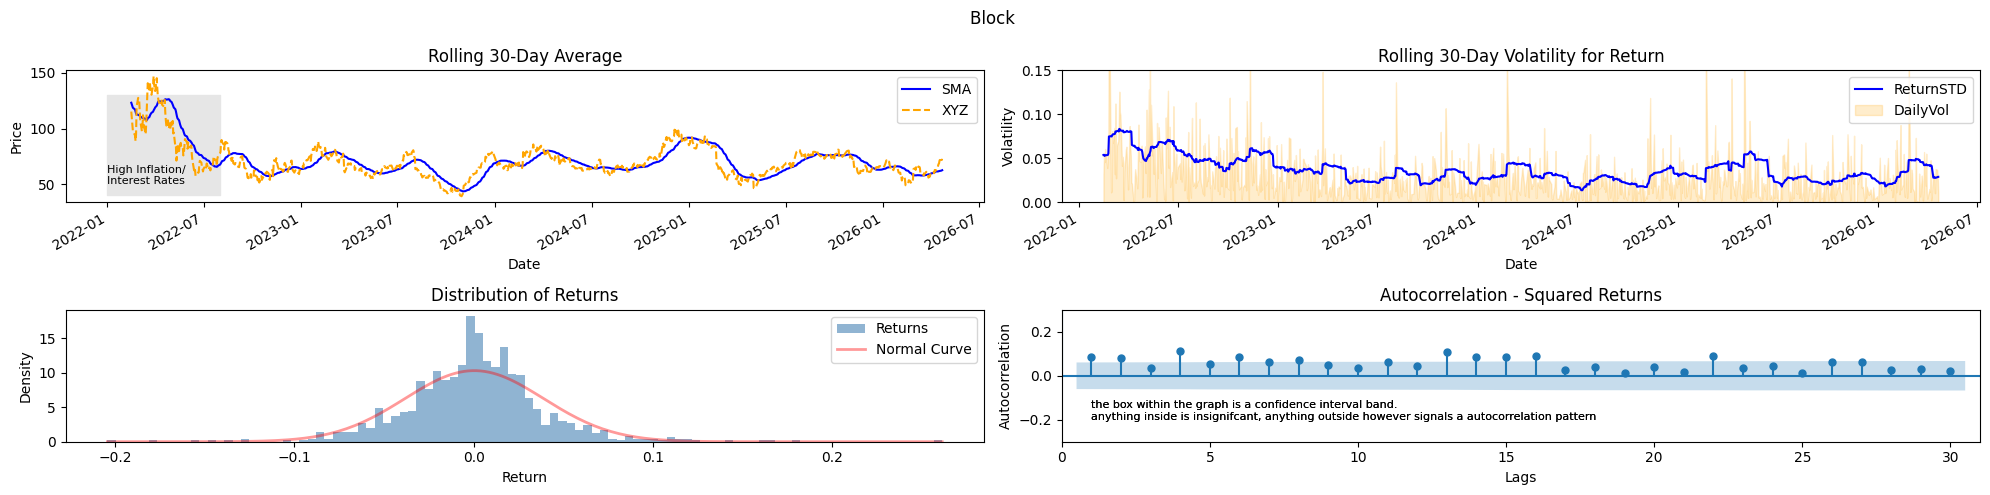

In [40]:
# 1: Block


# adds time as our x axis automatically due to it being a Datetime Index
blockfig,axes = plt.subplots(2,2,figsize=(20,5))
blockfig.suptitle("Block ")

#Graph 1
block.SMA.plot(ax=axes[0][0],color="blue",title="Rolling 30-Day Average", xlabel="Date", ylabel="Price", label='SMA')
block.Close.plot(ax=axes[0][0], color='orange', linestyle='--', label='Close')
axes[0][0].legend(loc='upper right')
axes[0][0].fill_betweenx([40,130],["2022-01"],["2022-08"],color="0.9")
axes[0][0].text("2022-01",50, 'High Inflation/\nInterest Rates', fontsize=8, color='black')

#Graph 2
block.ReturnSTD.plot(ax=axes[0][1],color="blue",title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Volatility")
axes[0][1].fill_between(block.index, block.DailyReturnSTD, alpha=0.2, color='orange', label='DailyVol')
axes[0][1].legend(loc='upper right')
axes[0][1].set_ylim(0, 0.15)

#Graph 3
block.Return.plot(ax=axes[1][0], kind='hist', bins=100, density=True,color='steelblue', alpha=0.6, title='Distribution of Returns',xlabel='Return', ylabel='Density', label='Returns')
mu, std = stats.norm.fit(block.Return.dropna())
# creates a smooth line to cast over the returns of block
x = np.linspace(block.Return.min(), block.Return.max(), 200)
axes[1][0].plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2,alpha=0.4, label='Normal Curve')
axes[1][1].text(1,-0.2, 'the box within the graph is a confidence interval band. \nanything inside is insignifcant, anything outside however signals a autocorrelation pattern', fontsize=8, color='black')
axes[1][0].legend()

#Graph 4
plot_acf(block.Return**2,lags=30,ax=axes[1][1])
axes[1][1].set_title("Autocorrelation - Squared Returns")
axes[1][1].set_xlabel("Lags")
axes[1][1].set_ylabel("Autocorrelation")
axes[1][1].set_ylim(-0.3, 0.3)
axes[1][1].set_xlim(0,31)
axes[1][1].text(1,-0.2, 'the box within the graph is a confidence interval band. \nanything inside is insignifcant, anything outside however signals a autocorrelation pattern', fontsize=8, color='black')




# make layout spaced out properly and show the graphs -> plt.show not needed in jupyter notebooks
plt.tight_layout()
plt.show()

### EDA Summary - Block

The 4-panel analysis reveals four key properties: price exhibits mean
reversion behavior around the rolling 30-day average,as the prices remain fairly stationary; volatility clusters in high and low regimes, elevated in 2022 then decaying, distribution of returns aren't normal, with fat tails appearing in both ends, dismissing any ideas for applying constant variance mdoels, and squared returns show
persistent autocorrelation across 30 lags. Together, these findings justify fitting GARCH-family models to capture the time-varying volatility structure.


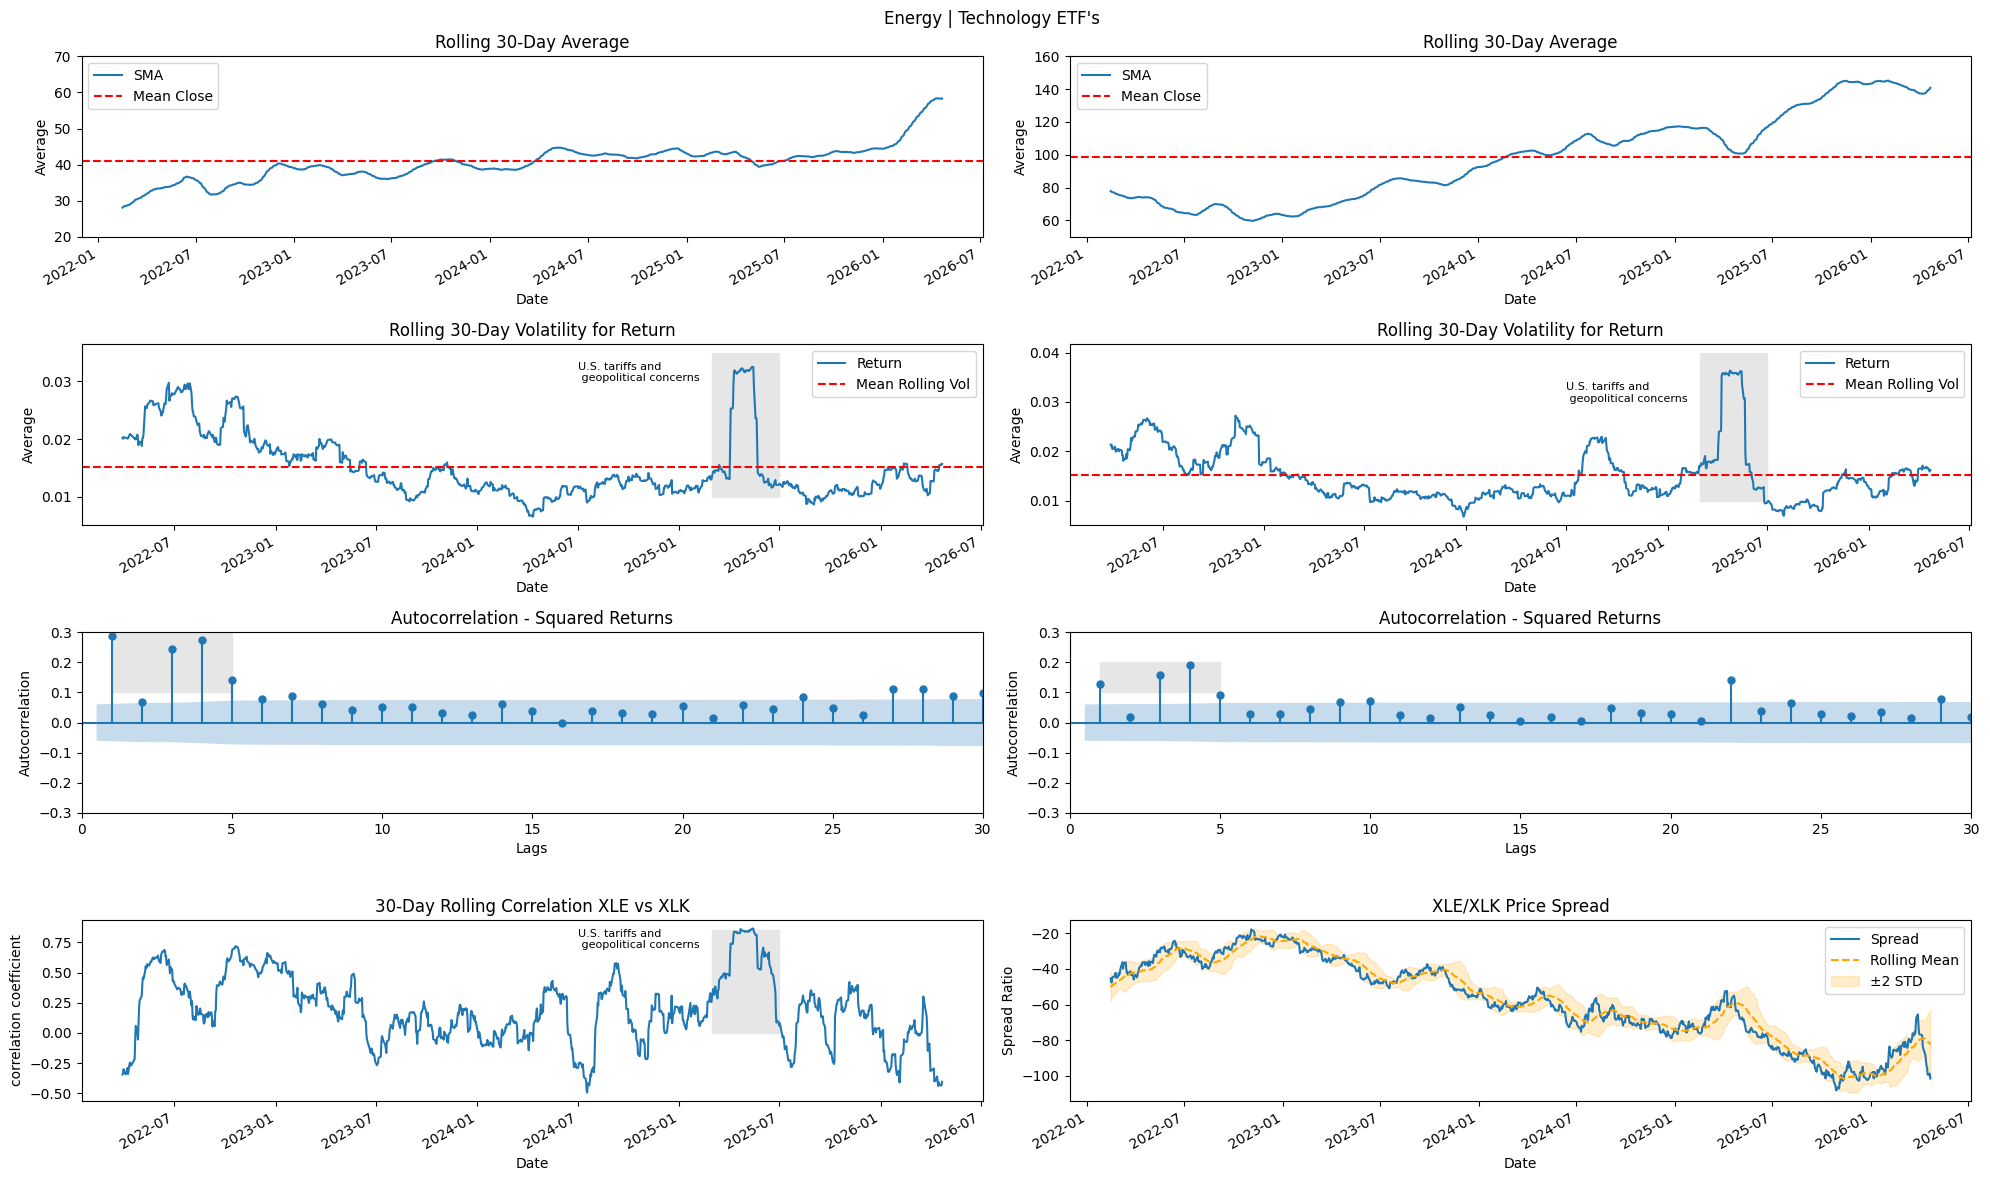

In [44]:
# 2: Energy and Technology ETF's

Etffig,etfaxes = plt.subplots(4,2,figsize=(20,12))
Etffig.suptitle("Energy | Technology ETF's ")

#Energy Graph 1 Rolling Avg
energy.SMA.plot(ax=etfaxes[0][0],title="Rolling 30-Day Average", xlabel="Date", ylabel="Average")
etfaxes[0][0].axhline(y=energy.Close.mean().mean(), color='red', linestyle='--', label='Mean Close')
etfaxes[0][0].legend(loc='upper left')
etfaxes[0][0].set_ylim(20, 70)

#Technology Graph 2 Rolling Avg
technology.SMA.plot(ax=etfaxes[0][1],title="Rolling 30-Day Average", xlabel="Date", ylabel="Average")
etfaxes[0][1].axhline(y=technology.Close.mean().mean(), color='red', linestyle='--', label='Mean Close')
etfaxes[0][1].legend(loc='upper left')
etfaxes[0][1].set_ylim(50, 160)

#Energy Graph 3 Rolling Volality
energy.Return.rolling(window=30).std().plot(ax=etfaxes[1][0],title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Average")
etfaxes[1][0].axhline(y=energy.Return.rolling(30).std().mean(), color='red', linestyle='--', label='Mean Rolling Vol')
etfaxes[1][0].legend(loc='upper right')
etfaxes[1][0].fill_betweenx([0.01,0.035],["2025-03"],["2025-07"],color="0.9")
etfaxes[1][0].text("2024-07",0.03, 'U.S. tariffs and \n geopolitical concerns', fontsize=8, color='black')

#Technology Graph 4 Rolling Volality
technology.Return.rolling(window=30).std().plot(ax=etfaxes[1][1],title="Rolling 30-Day Volatility for Return",xlabel="Date",ylabel="Average")
etfaxes[1][1].axhline(y=technology.Return.rolling(30).std().mean(), color='red', linestyle='--', label='Mean Rolling Vol')
etfaxes[1][1].legend(loc='upper right')
etfaxes[1][1].fill_betweenx([0.01,0.04],["2025-03"],["2025-07"],color="0.9")
etfaxes[1][1].text("2024-07",0.03, 'U.S. tariffs and \n geopolitical concerns', fontsize=8, color='black')

#Graph 5 Energy Squared Return
plot_acf(energy.Return**2,lags=30,ax=etfaxes[2][0])
etfaxes[2][0].set_title("Autocorrelation - Squared Returns")
etfaxes[2][0].set_xlabel("Lags")
etfaxes[2][0].set_ylabel("Autocorrelation")
etfaxes[2][0].fill_betweenx([0.1,0.3],1,5,color="0.9")
etfaxes[2][0].set_ylim(-0.3, 0.3)
etfaxes[2][0].set_xlim(0,30)

#Graph 6 Technology Squared Return
plot_acf(technology.Return**2,lags=30,ax=etfaxes[2][1])
etfaxes[2][1].set_title("Autocorrelation - Squared Returns")
etfaxes[2][1].set_xlabel("Lags")
etfaxes[2][1].set_ylabel("Autocorrelation")
etfaxes[2][1].fill_betweenx([0.1,0.2],1,5,color="0.9")
etfaxes[2][1].set_ylim(-0.3, 0.3)
etfaxes[2][1].set_xlim(0,30)


# Graph 7 rolling correlation
energy.Return.rolling(30).corr(technology.Return).plot(ax=etfaxes[3][0], title='30-Day Rolling Correlation XLE vs XLK')
etfaxes[3][0].fill_betweenx([0,0.85],["2025-03"],["2025-07"],color="0.9")
etfaxes[3][0].text("2024-07",0.70, 'U.S. tariffs and \n geopolitical concerns', fontsize=8, color='black')
etfaxes[3][0].set_ylabel("correlation coefficient")


#Graph 8 Price spread
spread.plot(ax=etfaxes[3][1], title="XLE/XLK Price Spread", xlabel="Date", ylabel="Spread Ratio", label='Spread')
spread_mean.plot(ax=etfaxes[3][1], color='orange', linestyle='--', label='Rolling Mean')
etfaxes[3][1].fill_between(spread_mean.index,(spread_mean + 2*spread_std),(spread_mean - 2*spread_std),alpha=0.2, color='orange', label='±2 STD')
etfaxes[3][1].legend(loc='upper right')


# make layout spaced out properly and show the graphs -> plt.show not needed in jupyter notebooks
plt.tight_layout()
plt.show()



### EDA Summary - Energy and Technology ETF

Both XLE and XLK show signs of non-stationarity in levels, with XLK in a steady
secular uptrend and XLE plateauing until early 2026 where it proceeded to a sharp
breakout. Both show volatility clustering, specifically during 2025 with the US
tariff and geopolitical issues occurring, setting up for exploring GARCH-family
models. The ETFs show significant autocorrelation in squared returns at lags 1,
3, and 4, telling us volatility is predictable from its own past. The most
interesting part is the rolling correlation, with it being highly unstable and
switching from roughly -0.5 to +0.85, killing the idea of running any constant
correlation models. The XLE/XLK price spread trends downward from -20 to -100
over the sample instead of mean-reverting, which kills any naive pairs trade
assuming a stable relationship.


# Statistical Modeling/Forecasting

---------------------------------------------STATISTICAL MODELING---------------------------------------------
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -2889.37
Distribution:                  Normal   AIC:                           5784.74
Method:            Maximum Likelihood   BIC:                           5799.61
                                        No. Observations:                 1049
Date:                Thu, Apr 23 2026   Df Residuals:                     1048
Time:                        00:51:41   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
--------------------------------

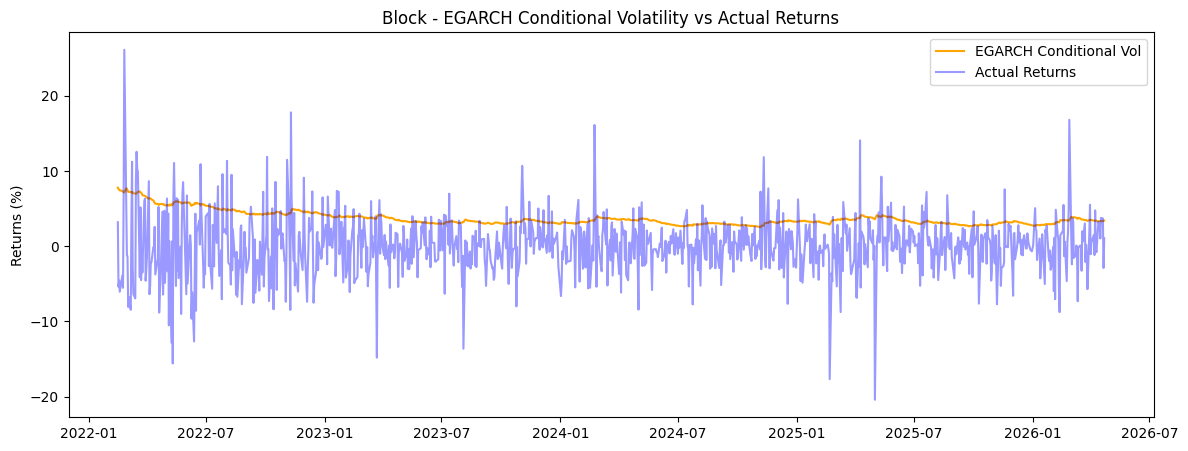

In [28]:
#BLOCK

# P represents the number of past squared return shocks included; 1 means yesterday shock fits into todays volatility
# q represents the number of past variance terms included.
# ARCH (1)
arch = arch_model(block.Return * 100, vol='ARCH', p=1)
arch_result = arch.fit(disp='off')

# GARCH(1,1)
garch = arch_model(block.Return * 100, vol='Garch', p=1, q=1)
garch_result = garch.fit(disp='off')

# EGARCH (1)
egarch = arch_model(block.Return * 100, vol='EGarch', p=1, q=1)
egarch_result = egarch.fit(disp='off')
print("---------------------------------------------STATISTICAL MODELING---------------------------------------------")
print(arch_result.summary())
print(garch_result.summary())
print(egarch_result.summary())
print("---------------------------------------------FORECAST---------------------------------------------")

#multiply by 100 since percentages are whole numbers
block_train = (block.Return[:-30]*100)   # everything except last 30 days
block_test = (block.Return[-30:] * 100)   # last 30 days as "future" data

# fit model on train
block_model = arch_model(block_train, vol='EGarch', p=1, q=1)
result = block_model.fit(disp='off')

# forecast 30 days
forecasts = result.forecast(horizon=30,method='simulation', simulations=1000)
predicted_vol = np.sqrt(forecasts.variance.values[-1])

# compare against realized vol in test set
realized_vol = block_test.abs().values

mae = np.mean(np.abs(predicted_vol - realized_vol))
print(f"MAE: {mae:.4f}")
print(f"Mean realized vol: {realized_vol.mean():.4f}")
print(f"Std realized vol: {realized_vol.std():.4f}")
print(f"MAE as % of mean vol: {mae/realized_vol.mean()*100:.1f}%")

naive_mae = np.mean(np.abs(block_train.abs().mean() - realized_vol))
print(f"Naive MAE: {naive_mae:.4f}")
print(f"EGARCH MAE: {mae:.4f}")
print(f"Improvement over naive: {((naive_mae - mae)/naive_mae)*100:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(egarch_result.conditional_volatility, color='orange', label='EGARCH Conditional Vol')
ax.set_ylabel('Returns (%)')
ax.plot(block.Return.dropna() * 100, color='blue', alpha=0.4, label='Actual Returns')
ax.set_title('Block - EGARCH Conditional Volatility vs Actual Returns')
ax.legend()

### Statistical Modeling Summary - Block (XYZ)

Fitted ARCH(1), GARCH(1,1), and EGARCH(1,1) on Block's returns. EGARCH won on
AIC/BIC (5677 vs 5682 vs 5785) but the margin over GARCH is small and the fit
itself is weak: GARCH's alpha came out 0.000 (p=1.000), meaning the model found
no significant reaction to past shocks, with beta pinned at 0.99. Combined with
the squared-return ACF sitting mostly inside the confidence band in EDA, this
says Block has weak ARCH effects compared to the sector ETFs, so GARCH-family
models have little signal to work with. The forecast evaluation confirms this
as EGARCH's MAE of 2.13 is 31.6% worse than a naive "yesterday's vol
equals tomorrow's vol" baseline (MAE 1.62). For Block, the fancy model is
actively worse than doing the naive model. The fat-tailed return distribution also suggests a t or skew-t innovation would fit better than Normal, but that
addresses distributional fit. A realized-vol or implied-vol approach would likely outperform here.

XLE EGARCH AIC: 3841.62
XLE EGARCH BIC: 3861.44
XLK EGARCH AIC: 3835.29
XLK EGARCH BIC: 3855.12


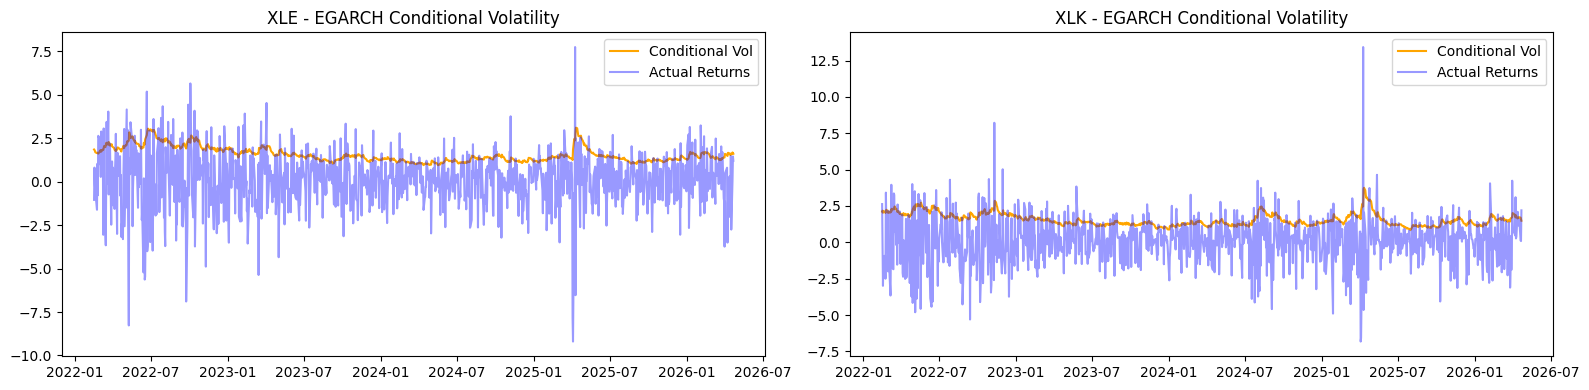

Input shape: (1049, 2)

DCC fitted parameters:
  a:     0.0101
  b:     0.9400
  a+b:   0.9502
  dof:   4.00

10-day ahead covariance forecast:
{'dist': 't', 'dof': np.float64(3.9999999897214735), 'cov': array([[ 3.95868093, -0.05518222],
       [-0.05518222,  3.44890894]])}


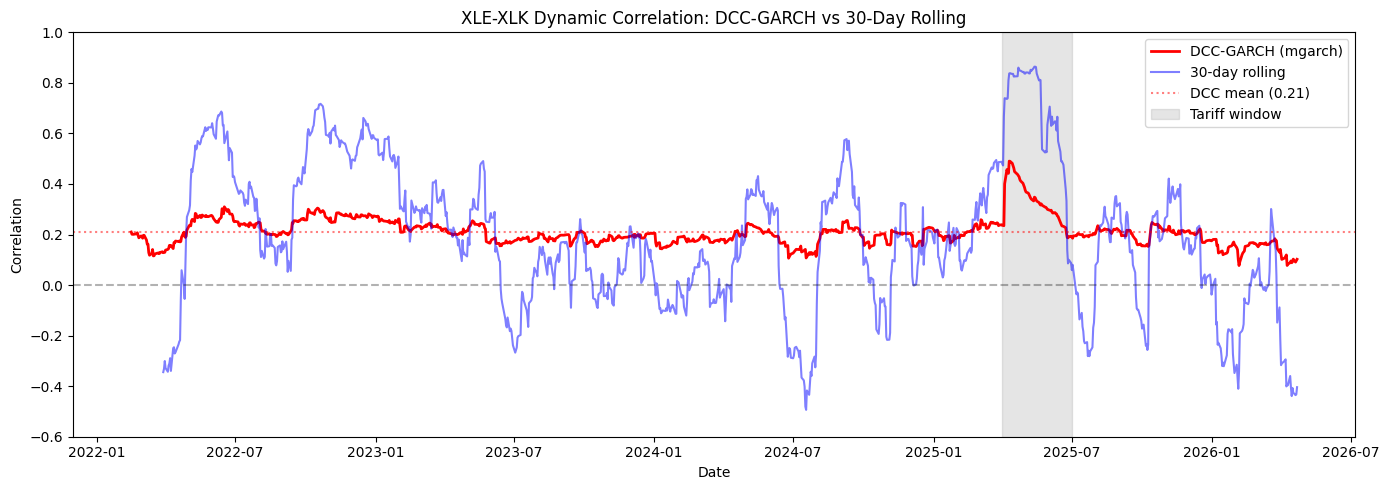


DCC correlation stats:
  Mean: 0.209
  Min:  0.077  on 2026-02-05
  Max:  0.490  on 2025-04-10

Regime comparison:
  Tariff window:  0.331
  Rest of sample: 0.202


In [56]:

# ============ EGARCH for XLE and XLK ============
xle_returns = (energy.Return * 100).dropna()
xlk_returns = (technology.Return * 100).dropna()

# XLE
xle_egarch = arch_model(xle_returns, vol='EGarch', p=1, q=1).fit(disp='off')
print("XLE EGARCH AIC:", round(xle_egarch.aic, 2))
print("XLE EGARCH BIC:", round(xle_egarch.bic, 2))

# XLK
xlk_egarch = arch_model(xlk_returns, vol='EGarch', p=1, q=1).fit(disp='off')
print("XLK EGARCH AIC:", round(xlk_egarch.aic, 2))
print("XLK EGARCH BIC:", round(xlk_egarch.bic, 2))

# Conditional vol plots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(xle_returns.index, xle_egarch.conditional_volatility, color='orange', label='Conditional Vol')
axes[0].plot(xle_returns.index, xle_returns.values, color='blue', alpha=0.4, label='Actual Returns')
axes[0].set_title('XLE - EGARCH Conditional Volatility')
axes[0].legend()

axes[1].plot(xlk_returns.index, xlk_egarch.conditional_volatility, color='orange', label='Conditional Vol')
axes[1].plot(xlk_returns.index, xlk_returns.values, color='blue', alpha=0.4, label='Actual Returns')
axes[1].set_title('XLK - EGARCH Conditional Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============ Step 1: Prepare returns matrix (per docs: shape (t, n)) ============
returns_matrix = pd.DataFrame({
    'XLE': xle_returns,
    'XLK': xlk_returns
}).dropna()

rt = returns_matrix.values  # numpy matrix, shape (t, n)
print(f"Input shape: {rt.shape}")

# ============ Step 2: Fit DCC-GARCH with t-distribution (per docs) ============
dist = 't'
vol = mgarch(dist)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=RuntimeWarning)
    vol.fit(rt)

print(f"\nDCC fitted parameters:")
print(f"  a:     {vol.a:.4f}")
print(f"  b:     {vol.b:.4f}")
print(f"  a+b:   {vol.a + vol.b:.4f}")
print(f"  dof:   {vol.dof:.2f}")

# ============ Step 3: Use .predict() as docs show (forecast next n days) ============
ndays = 10
cov_nextday = vol.predict(ndays)
print(f"\n{ndays}-day ahead covariance forecast:")
print(cov_nextday)

# ============ Step 4: Reconstruct in-sample dynamic correlation ============
#

# Standardize the returns (mgarch internally standardizes, we mirror it for the recursion)
# Simple approach: use returns directly, since mgarch.a and mgarch.b were fit on these
std_resid_df = pd.DataFrame({
    'XLE': xle_egarch.resid / xle_egarch.conditional_volatility,
    'XLK': xlk_egarch.resid / xlk_egarch.conditional_volatility
}).dropna()

eps = std_resid_df.values
T = len(eps)
Q_bar = np.cov(eps.T)
a, b = vol.a, vol.b

Q = Q_bar.copy()
dcc_corr_vals = np.zeros(T)
dcc_corr_vals[0] = Q_bar[0, 1] / np.sqrt(Q_bar[0, 0] * Q_bar[1, 1])

for t in range(1, T):
    Q = (1 - a - b) * Q_bar + a * np.outer(eps[t-1], eps[t-1]) + b * Q
    dcc_corr_vals[t] = Q[0, 1] / np.sqrt(Q[0, 0] * Q[1, 1])

dcc_corr = pd.Series(dcc_corr_vals, index=std_resid_df.index)

# ============ Step 5: Empirical rolling for comparison ============
rolling_corr = energy.Return.rolling(30).corr(technology.Return)

# ============ Step 6: Plot ============
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dcc_corr.index, dcc_corr, label='DCC-GARCH (mgarch)', color='red', linewidth=2)
ax.plot(rolling_corr.index, rolling_corr, label='30-day rolling', color='blue', alpha=0.5)
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.axhline(dcc_corr.mean(), color='red', linestyle=':', alpha=0.5,
           label=f'DCC mean ({dcc_corr.mean():.2f})')
ax.axvspan(pd.Timestamp('2025-04-01'), pd.Timestamp('2025-07-01'),
           color='gray', alpha=0.2, label='Tariff window')
ax.set_title('XLE-XLK Dynamic Correlation: DCC-GARCH vs 30-Day Rolling')
ax.set_ylabel('Correlation')
ax.set_xlabel('Date')
ax.legend(loc='best')
ax.set_ylim(-0.6, 1.0)
plt.tight_layout()
plt.show()

# ============ Diagnostics ============
print(f"\nDCC correlation stats:")
print(f"  Mean: {dcc_corr.mean():.3f}")
print(f"  Min:  {dcc_corr.min():.3f}  on {dcc_corr.idxmin().date()}")
print(f"  Max:  {dcc_corr.max():.3f}  on {dcc_corr.idxmax().date()}")

tariff_mask = (dcc_corr.index >= '2025-04-01') & (dcc_corr.index <= '2025-07-01')
print(f"\nRegime comparison:")
print(f"  Tariff window:  {dcc_corr[tariff_mask].mean():.3f}")
print(f"  Rest of sample: {dcc_corr[~tariff_mask].mean():.3f}")



### Statistical Modeling Summary - XLE and XLK

To test the hypotheses from EDA, I fit EGARCH(1,1) on each ETF and a DCC-GARCH
with t-distributed innovations on the pair. EGARCH captured the volatility
clustering cleanly, with conditional vol tracking returns tightly during stress
windows (XLE AIC: 3841, XLK AIC: 3835). The DCC fit returned a=0.0101, b=0.9400,
a+b=0.9502, meaning correlation is persistent but mean-reverting. The headline
result is the regime comparison: DCC correlation averaged 0.331 during the tariff
window versus 0.202 across the rest of the sample, a ~60% jump confirming XLE
and XLK co-move more during macro stress and killing any stable hedge ratio
assumption. One thing to note though is  standard DCC pulls toward the unconditional mean and
failed to capture the negative-correlation regimes the empirical rolling window
showed, so an ADCC or regime-switching extension would be the natural next step.
